# E-Commerce Analytics (EDA): Marketing, Funnel & Product Performance Analysis












 **Objective:** This project looks at Fuzzy Factory's marketing, website, and
sales data to understand why so many visitors don't turn into repeat customers. It traces the customer journey from first visit to purchase (and beyond) to find where people drop off and which products/campaigns actually make money. The goal is to turn these findings into clear, practical recommendations to improve conversions and retention.


## Loading Libraries and Data


In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import uniform, poisson, geom, expon, norm, binom
import math
import sqlite3 as sql

PALETTE_PRIMARY = ["royalblue", "lightsteelblue"]
sns.set_style("white")

In [ ]:
!gdown 1iEuH05fa0xfz-40qUlxbjvohyBdAV8AO
!gdown 1sUQu--JUmZo0fdhAVxvAePpJiGJ43ePh
!gdown 16Y6Qqknn-W1PMFytEXWlBzKgo1aGNxFR
!gdown 1Z8g5J97mEWplOoe2_uKlaHkPU2nLTd1E
!gdown 1DrJ39sL4Ybsn2mZhRLJXeescLsonQWtR
!gdown 1aS1NCDWZ87l3H73PgBYZRgIzBNyXav7K


Downloading...
From: https://drive.google.com/uc?id=1iEuH05fa0xfz-40qUlxbjvohyBdAV8AO
To: /content/website_sessions.csv
100% 42.1M/42.1M [00:00<00:00, 68.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1sUQu--JUmZo0fdhAVxvAePpJiGJ43ePh
To: /content/website_pageviews.csv
100% 56.9M/56.9M [00:00<00:00, 91.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=16Y6Qqknn-W1PMFytEXWlBzKgo1aGNxFR
To: /content/products.csv
100% 225/225 [00:00<00:00, 985kB/s]
Downloading...
From: https://drive.google.com/uc?id=1Z8g5J97mEWplOoe2_uKlaHkPU2nLTd1E
To: /content/orders.csv
100% 1.82M/1.82M [00:00<00:00, 146MB/s]
Downloading...
From: https://drive.google.com/uc?id=1DrJ39sL4Ybsn2mZhRLJXeescLsonQWtR
To: /content/order_items.csv
100% 1.93M/1.93M [00:00<00:00, 157MB/s]
Downloading...
From: https://drive.google.com/uc?id=1aS1NCDWZ87l3H73PgBYZRgIzBNyXav7K
To: /content/order_item_refunds.csv
100% 74.0k/74.0k [00:00<00:00, 59.5MB/s]


In [ ]:
df_orders     = pd.read_csv('/content/orders.csv')
df_products   = pd.read_csv('/content/products.csv')
df_order_item = pd.read_csv('/content/order_items.csv')
df_refund     = pd.read_csv('/content/order_item_refunds.csv')
df_web_sess   = pd.read_csv('/content/website_sessions.csv')
df_web_page   = pd.read_csv('/content/website_pageviews.csv')


Data Base Schema

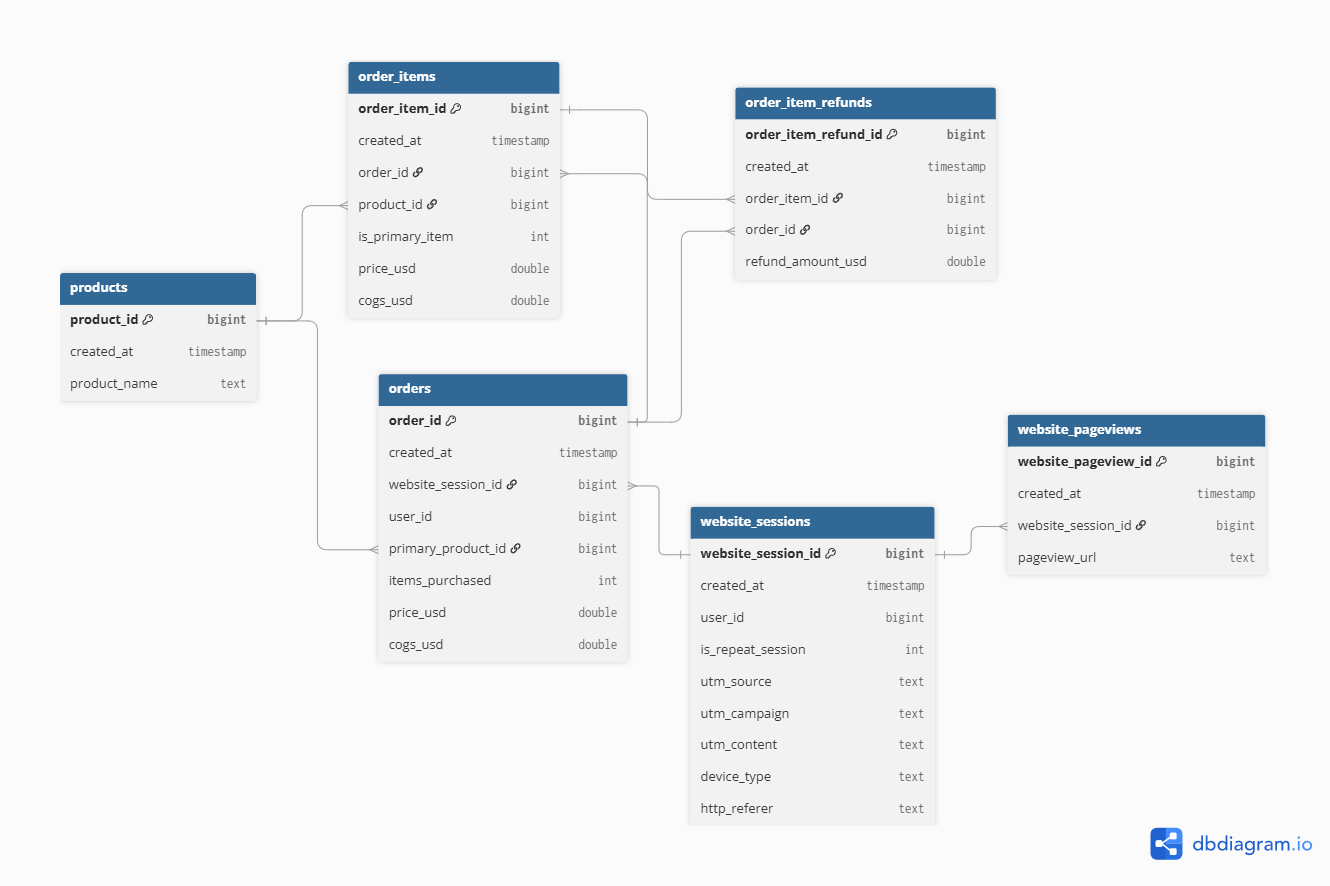

## Data Quality Checks(Basic Exploration)


### `orders` table


In [ ]:
# Preview the structure of the orders table
df_orders.head()


,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49


In [ ]:
# Confirm data types and check for missing values column-by-column
df_orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32313 entries, 0 to 32312
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            32313 non-null  int64  
 1   created_at          32313 non-null  object 
 2   website_session_id  32313 non-null  int64  
 3   user_id             32313 non-null  int64  
 4   primary_product_id  32313 non-null  int64  
 5   items_purchased     32313 non-null  int64  
 6   price_usd           32313 non-null  float64
 7   cogs_usd            32313 non-null  float64
dtypes: float64(2), int64(5), object(1)
memory usage: 2.0+ MB


In [ ]:
# checking unique rows for each column
df_orders.nunique()


,0
order_id,32313
created_at,32299
website_session_id,32313
user_id,31696
primary_product_id,4
items_purchased,2
price_usd,10
cogs_usd,10


### `website_sessions` table


In [ ]:
df_web_sess.head()


,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer
0,1,2012-03-19 08:04:16,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
1,2,2012-03-19 08:16:49,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
2,3,2012-03-19 08:26:55,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
3,4,2012-03-19 08:37:33,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
4,5,2012-03-19 09:00:55,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com


In [ ]:
df_web_sess.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472871 entries, 0 to 472870
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   website_session_id  472871 non-null  int64 
 1   created_at          472871 non-null  object
 2   user_id             472871 non-null  int64 
 3   is_repeat_session   472871 non-null  int64 
 4   utm_source          389543 non-null  object
 5   utm_campaign        389543 non-null  object
 6   utm_content         389543 non-null  object
 7   device_type         472871 non-null  object
 8   http_referer        432954 non-null  object
dtypes: int64(3), object(6)
memory usage: 32.5+ MB


In [ ]:
df_web_sess.nunique()


,0
website_session_id,472871
created_at,470444
user_id,394318
is_repeat_session,2
utm_source,3
utm_campaign,4
utm_content,6
device_type,2
http_referer,3


In [ ]:
df_web_sess.isna().sum()


,0
website_session_id,0
created_at,0
user_id,0
is_repeat_session,0
utm_source,83328
utm_campaign,83328
utm_content,83328
device_type,0
http_referer,39917


### Converting Strings to Datetime Objects

In [ ]:
All_Tables = [df_web_page, df_order_item, df_orders, df_refund, df_web_sess, df_products]

for i in All_Tables:
  i['created_at'] = pd.to_datetime(i['created_at'],errors='coerce')

df_web_page['year_month'] = df_web_page['created_at'].dt.strftime('%Y-%m')
df_order_item['year_month'] = df_order_item['created_at'].dt.strftime('%Y-%m')
df_web_sess['year_month'] = df_web_sess['created_at'].dt.strftime('%Y-%m')

### Filling null values

In [ ]:
# Fill missing UTM/channel fields with 'Direct'
df_web_sess.fillna('Direct', inplace=True)


### Connecting Data To SQL

In [ ]:
db = sql.connect('E-comm.db')

order_item = df_order_item.to_sql('order_item',db,if_exists='replace',index=False)
products = df_products.to_sql('products',db,if_exists='replace',index=False)
orders = df_orders.to_sql('orders',db,if_exists='replace',index=False)
web_pageview = df_web_page.to_sql('web_pageview',db,if_exists='replace',index=False)
web_session = df_web_sess.to_sql('web_session',db,if_exists='replace',index=False)
order_refund = df_refund.to_sql('order_refund',db,if_exists='replace',index=False)

## Exploaratry Data *Analysis* (EDA)


## Marketing and Funnel Analysis

**Business question:** Which channels/devices convert, and where do we lose
customers on the way to checkout?

We join `website_sessions` to `orders` on `website_session_id` + `user_id`
using a **left join**, so every session is retained whether or not it ended
in a purchase (*order_id* is `NaN` for sessions that didn't convert).


In [ ]:
df_merged = df_web_sess.merge(df_orders, how='left', on=['website_session_id', 'user_id'])
df_merged.head()


,website_session_id,created_at_x,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer,year_month,order_id,created_at_y,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 08:04:16,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,2012-03,NaN,NaT,NaN,NaN,NaN,NaN
1,2,2012-03-19 08:16:49,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,2012-03,NaN,NaT,NaN,NaN,NaN,NaN
2,3,2012-03-19 08:26:55,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,2012-03,NaN,NaT,NaN,NaN,NaN,NaN
3,4,2012-03-19 08:37:33,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,2012-03,NaN,NaT,NaN,NaN,NaN,NaN
4,5,2012-03-19 09:00:55,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,2012-03,NaN,NaT,NaN,NaN,NaN,NaN


### Overall Conversion Rate



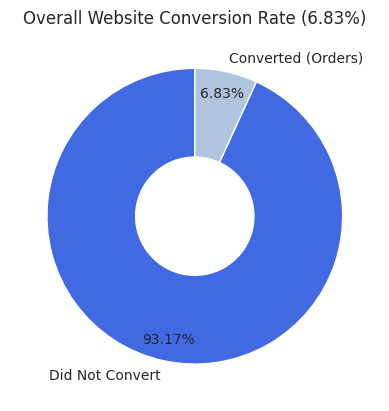

Total Sessions: 472,871
Total Orders  : 32,313


In [ ]:
Total_orders = df_merged['order_id'].count()          # sessions that converted (order_id present)
Total_session = df_merged['website_session_id'].count() # total sessions
did_not_convert = Total_session - Total_orders

label = ['Did Not Convert', 'Converted (Orders)']
sizes = [did_not_convert, Total_orders]
conversion_rate = round(Total_orders * 100 / Total_session, 2)

plt.figure()
plt.pie(sizes, labels=label, autopct='%.2f%%', startangle=90,
        colors=PALETTE_PRIMARY, pctdistance=0.85,
        textprops={'fontsize': 10}, wedgeprops={'width': 0.6})
plt.title(f'Overall Website Conversion Rate ({conversion_rate}%)')
plt.show()

print(f'Total Sessions: {Total_session:,}')
print(f'Total Orders  : {Total_orders:,}')


The Conversation Rate is 6.83%only means marketing team doing well to land customer on website but customers aren't purchasing much we have to find the the reason 'why' it is happening.


---



### Conversion Rate by Marketing Campaign

Grouping by `utm_campaign` shows how each paid campaign turns
traffic into orders the key metric for deciding where to shift ad budget.


In [ ]:
campaign_stats = df_merged.groupby('utm_campaign').agg(Total_Sessions=('website_session_id', 'count'),
                                                        Total_Orders=('order_id', 'count'),
                                                       Total_sales=('price_usd','sum')).reset_index()

campaign_stats['campaign_pct'] = round(campaign_stats['Total_Orders']*100 / campaign_stats['Total_Sessions'], 2)



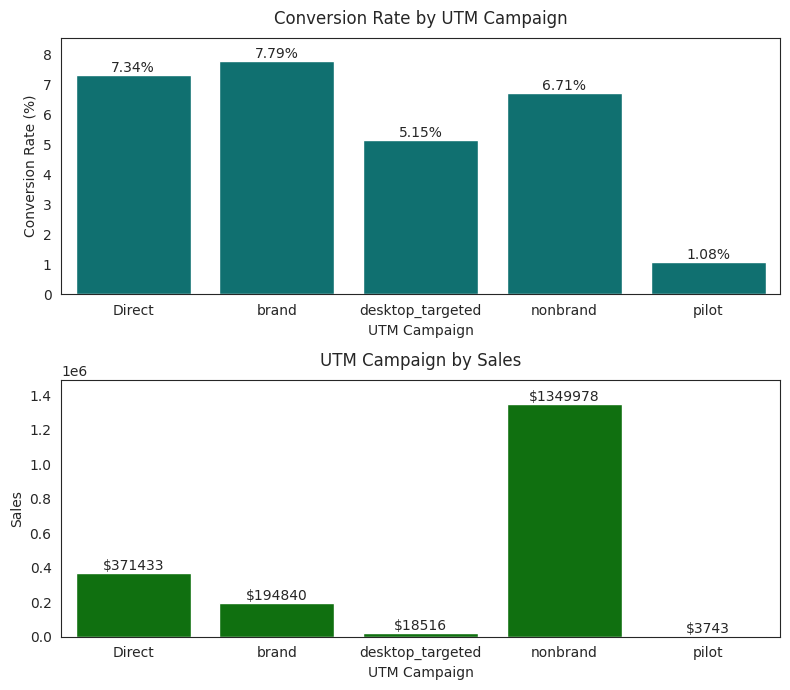

In [ ]:
plt.figure(figsize=(8, 7))

plt.subplot(2,1,1)
ax = sns.barplot(data=campaign_stats, x='utm_campaign', y='campaign_pct', color='teal')

# Label each bar with its exact conversion percentage
for i in ax.containers:
    ax.bar_label(i,fmt='%.2f%%')

plt.title('Conversion Rate by UTM Campaign', pad=10)
plt.xlabel('UTM Campaign')
plt.ylabel('Conversion Rate (%)')
plt.ylim(0, campaign_stats['campaign_pct'].max() * 1.1)# headroom for bar labels

plt.subplot(2,1,2)

ax = sns.barplot(data=campaign_stats, x='utm_campaign', y='Total_sales', color='green')
for i in ax.containers:
    plt.bar_label(i,fmt='$%.0f')

plt.title('UTM Campaign by Sales', pad=10)
plt.xlabel('UTM Campaign')
plt.ylabel('Sales')
plt.ylim(0,campaign_stats['Total_sales'].max()*1.1)
plt.tight_layout()

While the "brand" campaign converts best (7.79%) but contributes relatively little revenue ($194,840).

Whereas, "nonbrand" is the real revenue engine. It has a middling conversion rate (6.71%) but drives by far the most sales ($1.35M)


---



### Monthly Coversation Trend

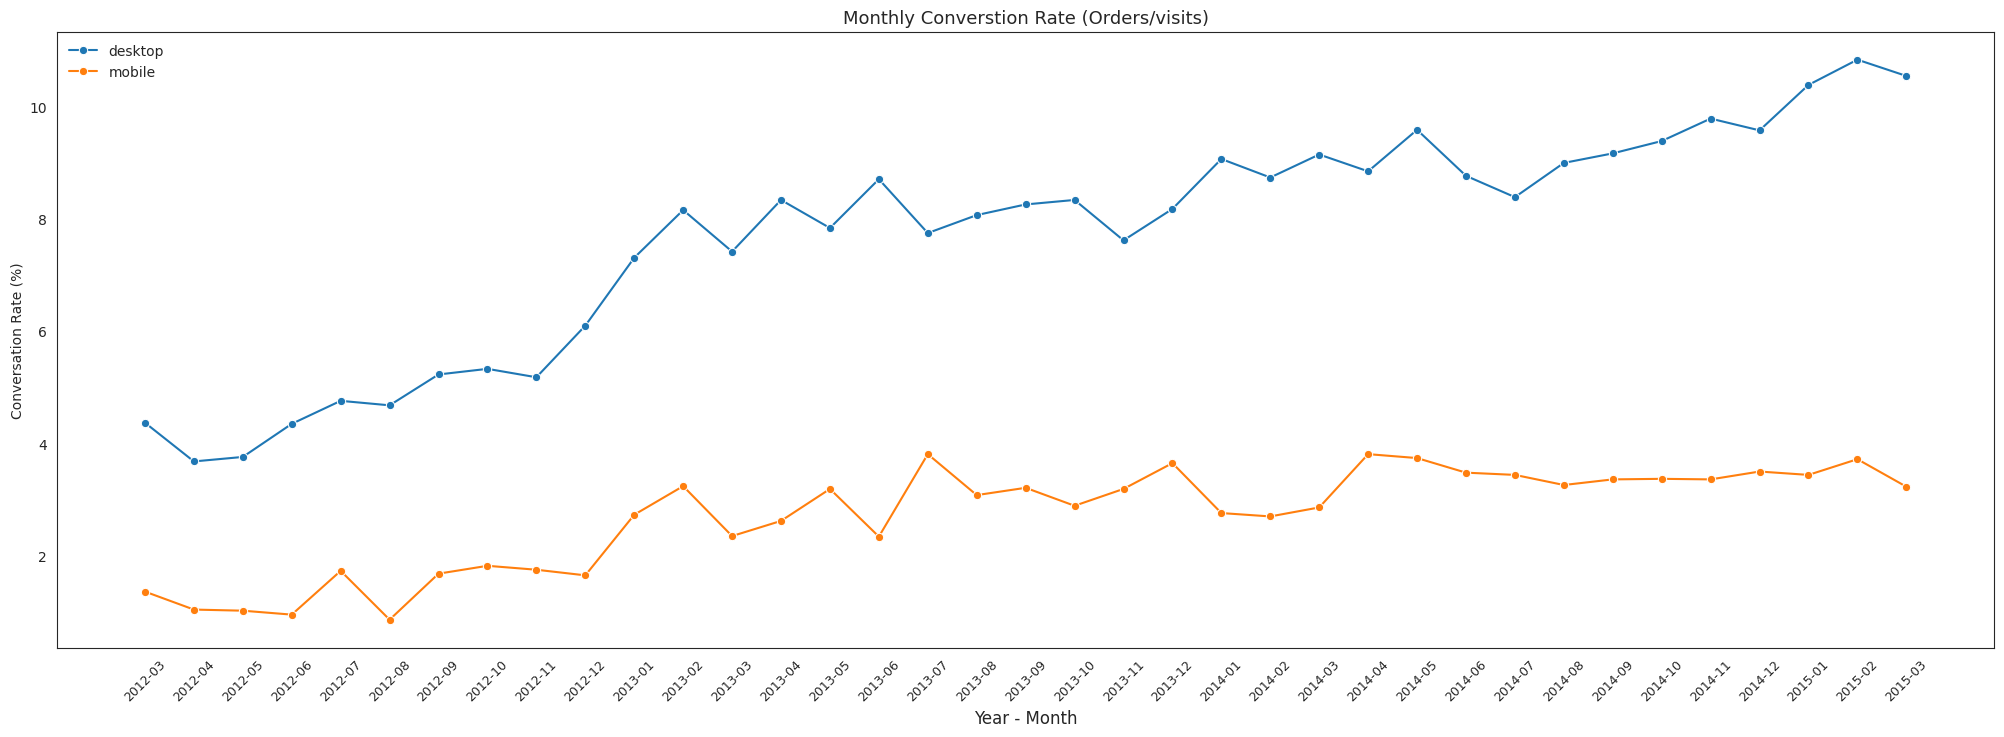

In [ ]:
monthly_stats = (df_merged.groupby(['year_month','device_type']).agg(total_session=('website_session_id', 'count'),
                                                       total_order=('order_id', 'count'))).reset_index()

monthly_stats['conv_pct'] = round(monthly_stats['total_order']*100 / monthly_stats['total_session'], 2)

plt.figure(figsize=(25,8))
sns.lineplot(data=monthly_stats, x='year_month', y= 'conv_pct',hue='device_type',marker='o')
plt.xticks(rotation=45,fontsize=9)
plt.title('Monthly Converstion Rate (Orders/visits)',fontsize=13)
plt.xlabel('Year - Month',fontsize=12)
plt.ylabel('Conversation Rate (%)')
plt.legend(frameon=False)
plt.show()

Desktop conversions grew steadily from 4% to over 10%. Meanwhile, mobile stayed stuck below 4%, making the gap between them much bigger over time.

### Conversion Rate by Device Type



In [ ]:
platform_stats = (df_merged.groupby('device_type').agg(total_sessions=('website_session_id', 'count'),
                                                       total_orders=('order_id', 'count')))

platform_stats['platform_pct'] = round(platform_stats['total_orders']*100 / platform_stats['total_sessions'], 2)
platform_stats


,total_sessions,total_orders,platform_pct
device_type,,,
desktop,327027,27805,8.50
mobile,145844,4508,3.09


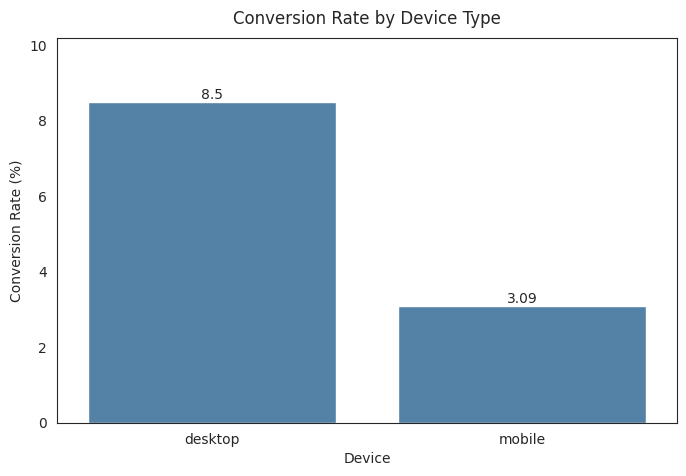

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=platform_stats, x=platform_stats.index, y='platform_pct', color='steelblue')

for i in ax.containers:
    ax.bar_label(i)

plt.title('Conversion Rate by Device Type', pad=10)
plt.xlabel('Device')
plt.ylabel('Conversion Rate (%)')
plt.ylim(0, platform_stats['platform_pct'].max() * 1.2)
plt.show()


Customers are more active in desktop than mobile. The conversation rate of desktop`8.5` is more than double of mobile`3.09`.


---



### New vs. Repeat Sessions

`is_repeat_session` flags whether a session came from a visitor who has been
to the site before. This shows how much of total traffic volume is driven by
returning visitors vs. fresh acquisition.


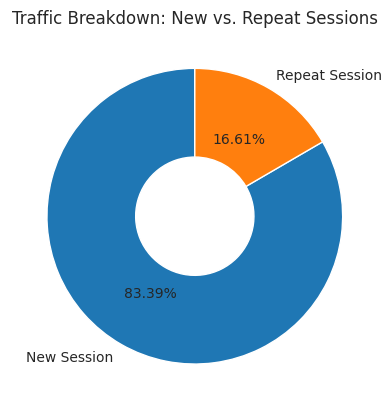

In [ ]:
repeat_session = df_merged['is_repeat_session'].sum()
total_session = len(df_merged)
new_session = total_session - repeat_session

label = ['New Session', 'Repeat Session']
sizes = [new_session, repeat_session]

plt.figure()
plt.pie(sizes, labels=label, startangle=90, autopct='%.2f%%', wedgeprops={'width': 0.6})
plt.title('Traffic Breakdown: New vs. Repeat Sessions')
plt.show()


Only 16.6% of total traffic returns to the site, meaning roughly 5 out of 6 visitors never come back its a sign of weak brand stickiness rather than a purchase problem since the business is paying to acquire most of its traffic fresh, again and again.


---



### Pageview-Level Funnel

`website_pageviews` table (one row per page viewed)
to reconstruct the actual browsing → checkout journey and see exactly where
visitors drop off.


In [ ]:
df_web_page.head()


,website_pageview_id,created_at,website_session_id,pageview_url,year_month
0,1,2012-03-19 08:04:16,1,/home,2012-03
1,2,2012-03-19 08:16:49,2,/home,2012-03
2,3,2012-03-19 08:26:55,3,/home,2012-03
3,4,2012-03-19 08:37:33,4,/home,2012-03
4,5,2012-03-19 09:00:55,5,/home,2012-03


In [ ]:
df_web_page.info()
# has 0 null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1188124 entries, 0 to 1188123
Data columns (total 5 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   website_pageview_id  1188124 non-null  int64         
 1   created_at           1188124 non-null  datetime64[ns]
 2   website_session_id   1188124 non-null  int64         
 3   pageview_url         1188124 non-null  object        
 4   year_month           1188124 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 45.3+ MB


In [ ]:
df_web_page.nunique()

,0
website_pageview_id,1188124
created_at,1171962
website_session_id,472871
pageview_url,16
year_month,37


### Cart Abandonment Rate

Defined as: of the sessions that reached **cart** and never made
**purchased**


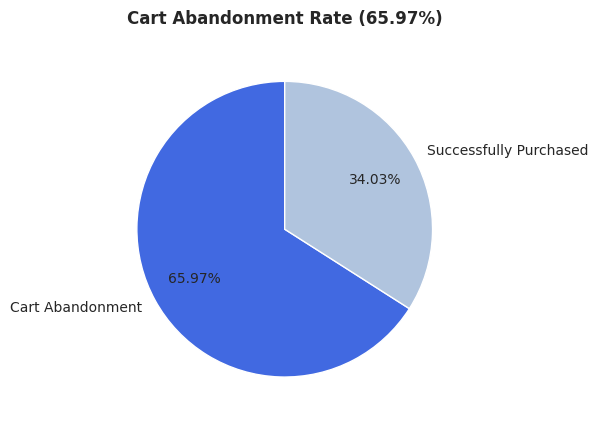

Cart Arrivals          : 94,953
Cart Abandonment       : 62,640
Successfully Purchased : 32,313


In [ ]:
sessions_to_cart = df_web_page.loc[df_web_page['pageview_url'] == '/cart', 'website_session_id'].nunique()

sessions_to_thank_you = df_web_page.loc[df_web_page['pageview_url'] == '/thank-you-for-your-order', 'website_session_id'].nunique()

cart_abandonment = sessions_to_cart - sessions_to_thank_you
abandonment_rate = round(100 - (sessions_to_thank_you * 100 / sessions_to_cart), 2)

label = ['Cart Abandonment', 'Successfully Purchased']
sizes = [cart_abandonment, Total_orders]

plt.figure()
plt.pie(sizes, labels=label, startangle=90, colors=PALETTE_PRIMARY,autopct='%.2f%%', pctdistance=0.70)

plt.title(f'Cart Abandonment Rate ({abandonment_rate}%)', pad=15, weight='bold')
plt.show()

print(f'Cart Arrivals          : {sessions_to_cart:,}')
print(f'Cart Abandonment       : {cart_abandonment:,}')
print(f'Successfully Purchased : {Total_orders:,}')


In [ ]:
df_web_page.head()

,website_pageview_id,created_at,website_session_id,pageview_url,year_month
0,1,2012-03-19 08:04:16,1,/home,2012-03
1,2,2012-03-19 08:16:49,2,/home,2012-03
2,3,2012-03-19 08:26:55,3,/home,2012-03
3,4,2012-03-19 08:37:33,4,/home,2012-03
4,5,2012-03-19 09:00:55,5,/home,2012-03


In [ ]:


query = '''
       select year_month,
       round((sum(case when pageview_url = '/cart' then 1 else 0 end) -
       sum(case when pageview_url = '/thank-you-for-your-order' then 1 else 0 end)) *100.0
          /sum(case when pageview_url = '/cart' then 1 else 0 end),2) as abandonment_rate_pct
       from web_pageview
       group by 1
       order by 1
       '''

df = pd.read_sql_query(query,db)




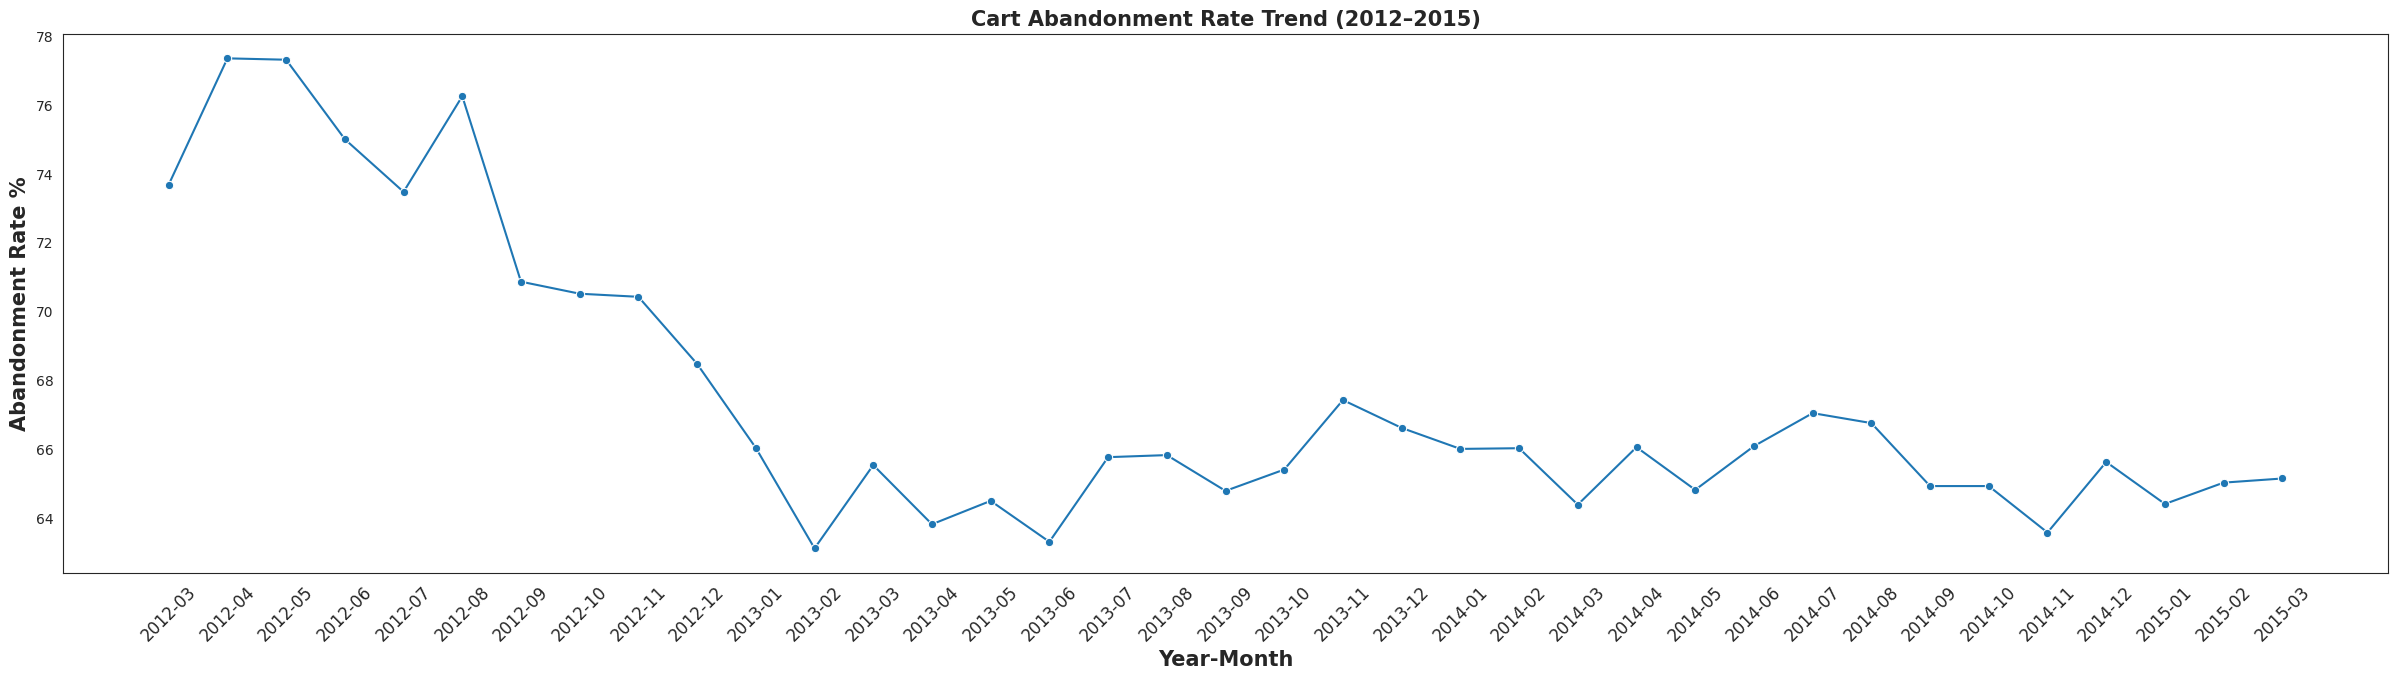

In [ ]:
plt.figure(figsize=(30,7))
sns.lineplot(data = df, x = 'year_month', y= 'abandonment_rate_pct',marker='o')
plt.xticks(rotation=45,fontsize=12)
plt.xlabel('Year-Month',fontsize=15,weight='bold')
plt.ylabel('Abandonment Rate %',fontsize=15,weight='bold')
plt.title('Cart Abandonment Rate Trend (2012–2015)',fontsize=15,weight='bold')
plt.show()

The cart abandonment rate saw a significant and sustained drop from a high of over 77% in mid-2012 down to roughly 63% by early 2013.
Following this sharp decline, the rate successfully stabilized, consistently fluctuating between 64% and 67% through early 2015.


---



### Funnel Stage Drop-off

Raw pageview URLs (e.g. `/products/fuzzy-bear`, `/products/forever-love`) are
grouped into standardized **funnel stages** using keyword matching, so we can
compare pageview volume at each step of the journey on a single chart and
spot exactly where the biggest drop-off occurs.


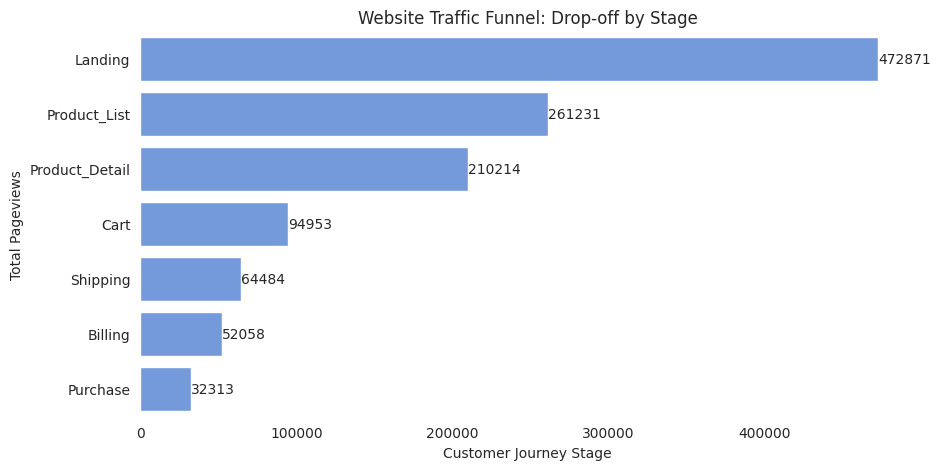

In [ ]:
# Map each raw URL to a standardized funnel stage using keyword matching
conditions = [
    df_web_page['pageview_url'].str.contains('home|lander', na=False), #na = False (If find any null don't raise error)
    df_web_page['pageview_url'].str.contains('products', na=False),
    df_web_page['pageview_url'].str.contains('fuzzy|forever|sugar|hudson', na=False),
    df_web_page['pageview_url'].str.contains('cart', na=False),
    df_web_page['pageview_url'].str.contains('shipping', na=False),
    df_web_page['pageview_url'].str.contains('billing', na=False),
    df_web_page['pageview_url'].str.contains('thank-you-for-your-order', na=False),
]

stages = ['Landing', 'Product_List', 'Product_Detail', 'Cart', 'Shipping', 'Billing', 'Purchase']

df_web_page['funnel_stage'] = np.select(conditions, stages, default='Other')#each row of each condition which staisfied the condition will connect to particular stages

plt.figure(figsize=(10, 5))
ax = sns.countplot(y=df_web_page['funnel_stage'], order=stages, color='cornflowerblue')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.xlabel('Customer Journey Stage')
plt.ylabel('Total Pageviews')
plt.title('Website Traffic Funnel: Drop-off by Stage')
plt.box(False)
plt.show()


The steepest drop-off happens right at the top of the funnel from 472,871 landing page views to just 261,231 reaching the product list the biggest single opportunity for improvement.


---



### Basket Size Distribution

How many items does the typical order contain? This matters for cross-sell
strategy: if most orders are single-item, there's untapped upside in
bundling or "frequently bought together" prompts.


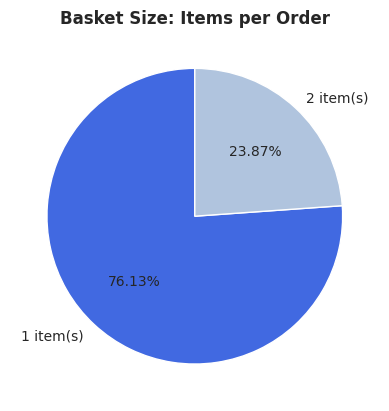

In [ ]:
# Distribution of orders by number of items purchased


basket_size = df_orders['items_purchased'].value_counts().sort_index()
labels = [f'{i} item(s)' for i in basket_size.index]

plt.figure()
plt.pie(basket_size, labels=labels, startangle=90, autopct='%.2f%%', colors=PALETTE_PRIMARY)
plt.title('Basket Size: Items per Order', weight='bold')
plt.show()


76% of customers buying just one item highlights a major lack of effective upselling. Adding "frequently bought together" recommendations can easily boost revenue per order without any extra marketing spend.


---



### Products which are commonly bought together

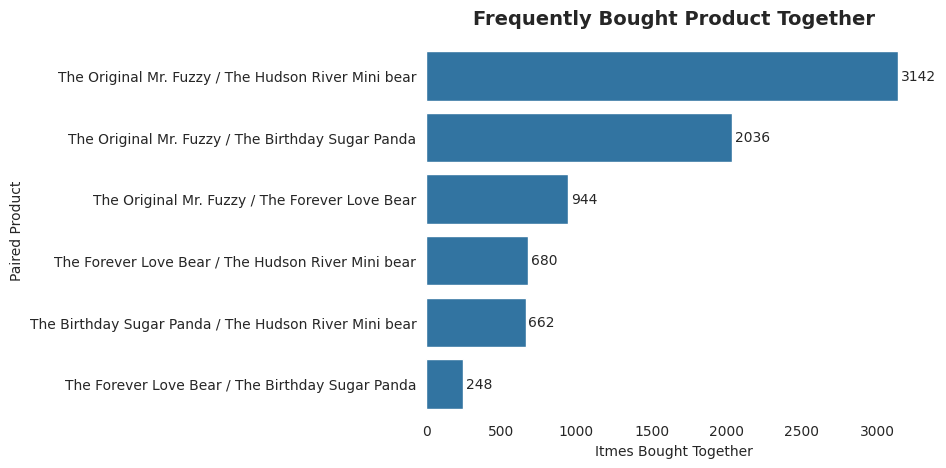

In [ ]:
query = '''
        select p.product_name as Product_A,p1.product_name as Product_B,count(*) items_bought_together
        from order_item o
        join order_item o1
        on o.product_id < o1.product_id
        and o.order_id = o1.order_id

        join products p
        on p.product_id = o.product_id

        join products p1
        on p1.product_id = o1.product_id
        group by p.product_name,p1.product_name
        order by items_bought_together desc
        '''
df = pd.read_sql_query(query,db)
df['Paired_product'] = df['Product_A'] +' / '+ df['Product_B']


ax = sns.barplot(data = df, y = 'Paired_product', x = 'items_bought_together')
for i in ax.containers:
  plt.bar_label(i,padding=2)
plt.grid(False)
plt.title('Frequently Bought Product Together', weight='bold', pad=15, fontsize=14)
sns.despine(bottom=True, left=True) # removes outerbox
plt.xlabel('Itmes Bought Together')
plt.ylabel('Paired Product')
plt.show()

Our top-selling product combination is "The Original Mr. Fuzzy" and "The Hudson River Mini bear." Since "The Original Mr. Fuzzy" appears in the top three pairs, it should be the primary focus for targeted cross-selling prompts at checkout.



---






## Product Performance Analysis

**Business question:** Which products are profitable once refunds
and cost of goods sold (COGS) are accounted for



In [ ]:
df_products.head()


,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


In [ ]:
df_order_item.head()


,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd,year_month
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49,2012-03
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49,2012-03
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49,2012-03
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49,2012-03
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49,2012-03


In [ ]:
df_order_item.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40025 entries, 0 to 40024
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_item_id    40025 non-null  int64         
 1   created_at       40025 non-null  datetime64[ns]
 2   order_id         40025 non-null  int64         
 3   product_id       40025 non-null  int64         
 4   is_primary_item  40025 non-null  int64         
 5   price_usd        40025 non-null  float64       
 6   cogs_usd         40025 non-null  float64       
 7   year_month       40025 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(1)
memory usage: 2.4+ MB


In [ ]:
df_order_item.nunique()


,0
order_item_id,40025
created_at,32299
order_id,32313
product_id,4
is_primary_item,2
price_usd,4
cogs_usd,4
year_month,37


In [ ]:
df_refund.head()


,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd
0,1,2012-04-06 11:32:43,57,57,49.99
1,2,2012-04-13 01:09:43,74,74,49.99
2,3,2012-04-15 07:03:48,71,71,49.99
3,4,2012-04-17 20:00:37,118,118,49.99
4,5,2012-04-22 20:53:49,116,116,49.99


In [ ]:
df_refund.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1731 entries, 0 to 1730
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   order_item_refund_id  1731 non-null   int64         
 1   created_at            1731 non-null   datetime64[ns]
 2   order_item_id         1731 non-null   int64         
 3   order_id              1731 non-null   int64         
 4   refund_amount_usd     1731 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 67.7 KB


In [ ]:
df_products

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


### Building Product-Level Table

`order_items` is left-joined to `products` (to get readable product names),
then left-joined to `order_item_refunds` (to attach refund amounts where they
exist). Left joins are used throughout so that items with **no** refund are
kept with `NaN` refund values, rather than being dropped.


In [ ]:
df_merged2 = df_order_item.merge(df_products, how='left', on='product_id')
df_final = df_merged2.merge(df_refund, how='left', on='order_item_id')

df_final.head()


,order_item_id,created_at_x,order_id_x,product_id,is_primary_item,price_usd,cogs_usd,year_month,created_at_y,product_name,order_item_refund_id,created_at,order_id_y,refund_amount_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49,2012-03,2012-03-19 08:00:00,The Original Mr. Fuzzy,NaN,NaT,NaN,NaN
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49,2012-03,2012-03-19 08:00:00,The Original Mr. Fuzzy,NaN,NaT,NaN,NaN
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49,2012-03,2012-03-19 08:00:00,The Original Mr. Fuzzy,NaN,NaT,NaN,NaN
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49,2012-03,2012-03-19 08:00:00,The Original Mr. Fuzzy,NaN,NaT,NaN,NaN
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49,2012-03,2012-03-19 08:00:00,The Original Mr. Fuzzy,NaN,NaT,NaN,NaN


### Product Economics Summary

For each product we compute:
- **Gross_sales** — total revenue billed to customers
- **Total_refund** — total dollars refunded
- **Net_Sales** — Gross sales minus refunds (what the business actually kept)
- **Total_cost** — cost of goods sold (COGS)
- **Net_Profit** — Net sales minus COGS (true bottom-line contribution)
- **return_rate** — % of units sold that were later returned


In [ ]:
product_summary_df = df_final.groupby('product_name').agg(
                            Gross_sales=('price_usd', 'sum'),
                            Total_refund=('refund_amount_usd', 'sum'),
                            Total_cost=('cogs_usd', 'sum'),
                            Total_item_sold=('order_item_id', 'count'),
                            Total_item_returned=('order_item_refund_id', 'count'),).reset_index()

product_summary_df['Net_Sales'] = product_summary_df['Gross_sales'] - product_summary_df['Total_refund']
product_summary_df['Net_Profit'] = product_summary_df['Net_Sales'] - product_summary_df['Total_cost']
product_summary_df['return_rate'] = round(
    product_summary_df['Total_item_returned'] * 100 / product_summary_df['Total_item_sold'], 2)

product_summary_df


,product_name,Gross_sales,Total_refund,Total_cost,Total_item_sold,Total_item_returned,Net_Sales,Net_Profit,return_rate
0,The Birthday Sugar Panda,229260.15,13842.99,72232.65,4985,301,215417.16,143184.51,6.04
1,The Forever Love Bear,347702.04,7738.71,130352.04,5796,129,339963.33,209611.29,2.23
2,The Hudson River Mini bear,150489.82,1919.36,47620.82,5018,64,148570.46,100949.64,1.28
3,The Original Mr. Fuzzy,1211057.74,61837.63,472164.74,24226,1237,1149220.11,677055.37,5.11


### Gross Sales vs. Net Sales vs. Refunds



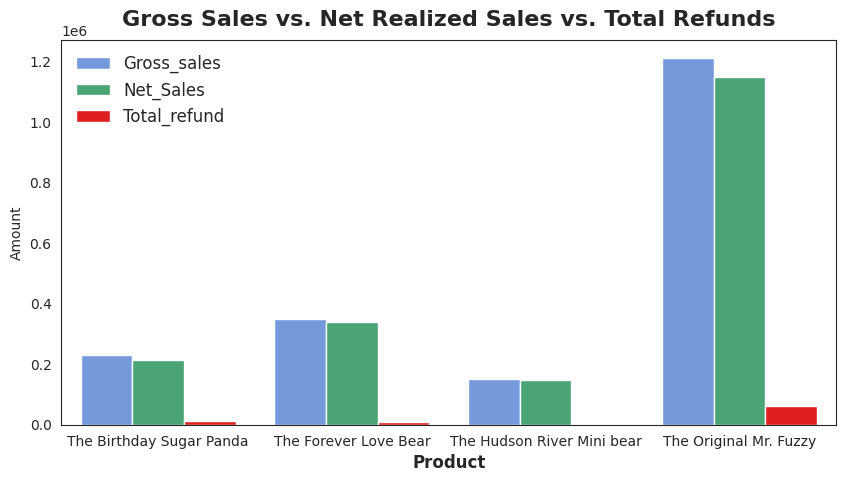

In [ ]:
#Reshaping the summary table into long format.

melted_sales_df = pd.melt(
    product_summary_df,
    id_vars='product_name',
    value_vars=['Gross_sales', 'Net_Sales', 'Total_refund'],
    var_name='Metric',
    value_name='Amount',
)

plt.figure(figsize=(10, 5))
sns.barplot(data=melted_sales_df, x='product_name', y='Amount', hue='Metric',
            palette=['cornflowerblue', 'mediumseagreen', 'red'])

plt.title('Gross Sales vs. Net Realized Sales vs. Total Refunds', pad=10, weight='bold', fontsize=16)
plt.xlabel('Product', weight='bold', fontsize=12)
plt.legend(title='', frameon=False, fontsize=12)
plt.show()


The Original Mr. Fuzzy has the highest Gross and Net Sales.


The other products has generated comparatively similar net sales


---



### Net Sales vs. Net Profit



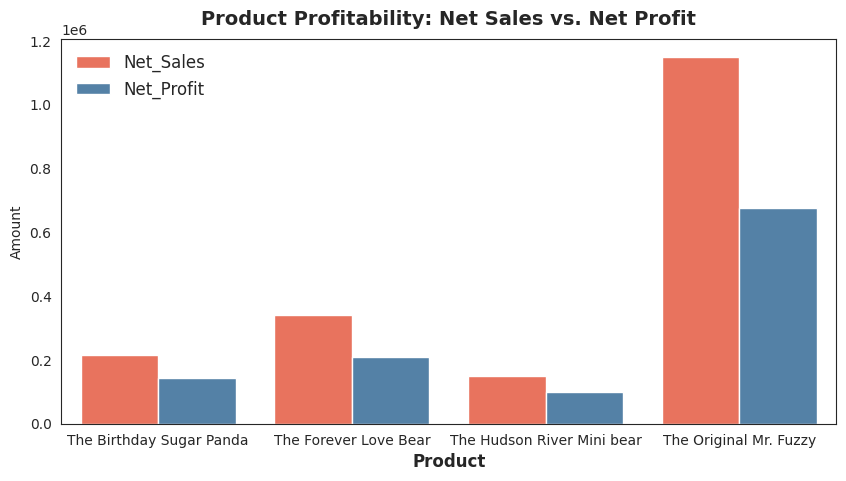

In [ ]:
melted_profit_df = pd.melt(
    product_summary_df,
    id_vars='product_name',
    value_vars=['Net_Sales', 'Net_Profit'],
    var_name='Metric',
    value_name='Amount',
)

plt.figure(figsize=(10, 5))
sns.barplot(data=melted_profit_df, x='product_name', y='Amount', hue='Metric',
            palette=["#FF6347", "#4682B4"])

plt.title('Product Profitability: Net Sales vs. Net Profit', pad=10, weight='bold', fontsize=14)
plt.xlabel('Product', weight='bold', fontsize=12)
plt.legend(title='', frameon=False, fontsize=12)
plt.show()


"The Original Mr. Fuzzy" overwhelmingly drives business performance, generating significantly more net sales and net profit than the other three products combined. The remaining products sales is much lower in overall volume, still maintain healthy profit margins relative to their sales.


---



### Return Rate by Product

High-return products erode margin twice over (lost sale + refund processing
often unsellable inventory)


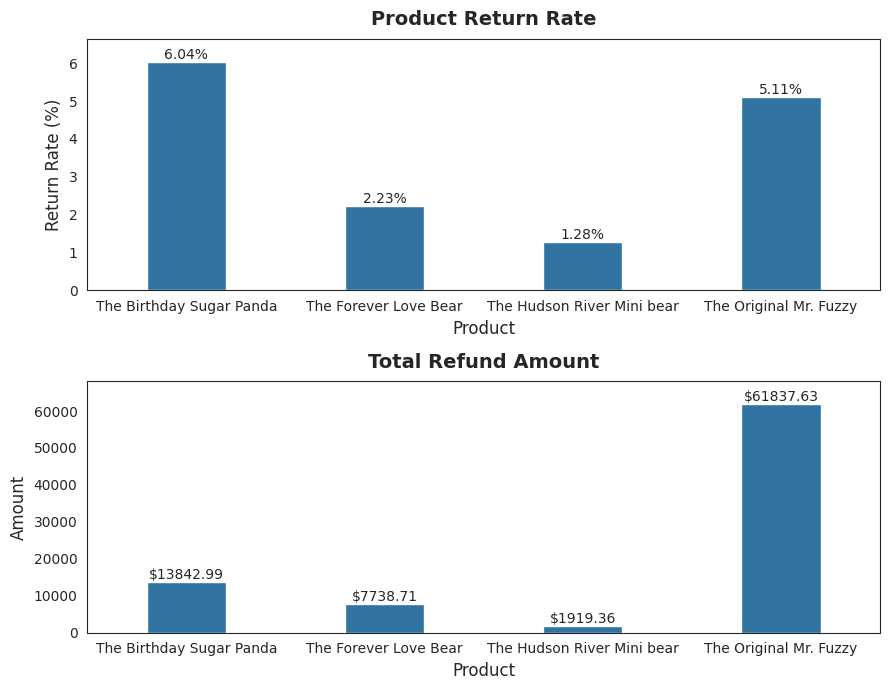

In [ ]:
plt.figure(figsize=(9, 7))

plt.subplot(2,1,1)
ax = sns.barplot(data=product_summary_df, x='product_name', y='return_rate', width=0.4)
for i in ax.containers:
  plt.bar_label(i,fmt='%.2f%%')
plt.title('Product Return Rate', pad=10, weight='bold', fontsize=14)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Return Rate (%)', fontsize=12)
plt.ylim(0,product_summary_df['return_rate'].max()*1.1)

plt.subplot(2,1,2)

ax = sns.barplot(data=product_summary_df, x='product_name', y='Total_refund', width=0.4)
for i in ax.containers:
  plt.bar_label(i,fmt='$%.2f')
plt.title('Total Refund Amount', pad=10, weight='bold', fontsize=14)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Amount', fontsize=12)
plt.ylim(0,product_summary_df['Total_refund'].max()*1.1)

plt.tight_layout()


"The Birthday Sugar Panda" has a high return rate of 6.04% despite lower sales, indicating a potential issue with product appeal or quality. However, the business must urgently prioritize quality control for "The Original Mr. Fuzzy." Because it is the top-selling product, its 5.11% return rate translates into a massive $61,838 financial drain, making it the most expensive product issue overall.

---



### Overall Return Rate (All Products)


In [ ]:
overall_return_rate = round(
    df_refund['order_item_refund_id'].count() * 100 / df_order_item['order_item_id'].count(), 2)
print(f'Overall return rate across all products: {overall_return_rate}%')


Overall return rate across all products: 4.32%


## Sales Trend & Seasonality Analysis

**Business question:** Is revenue per order growing over time, and are there
predictable seasonal patterns (by month or day of week) that should shape
inventory and marketing calendars?




### Average Order Value (AOV) Trend

Average order value is tracked by year-quarter to reveal whether customers
are spending more per order over time.


In [ ]:
df_order_item['day_of_week'] = df_order_item['created_at'].dt.day_name()

df_order_item.head()

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd,year_month,day_of_week
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49,2012-03,Monday
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49,2012-03,Monday
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49,2012-03,Tuesday
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49,2012-03,Tuesday
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49,2012-03,Tuesday


In [ ]:
yr_quartely_sales = df_order_item.groupby('year_month').agg(
    total_sales=('price_usd', 'sum'),
    total_orders=('order_id', 'nunique'),
).reset_index()

yr_quartely_sales['Average_order_value'] = (
    yr_quartely_sales['total_sales'] / yr_quartely_sales['total_orders']
)
yr_quartely_sales.head()


,year_month,total_sales,total_orders,Average_order_value
0,2012-03,2999.40,60,49.99
1,2012-04,4949.01,99,49.99
2,2012-05,5398.92,108,49.99
3,2012-06,6998.60,140,49.99
4,2012-07,8448.31,169,49.99


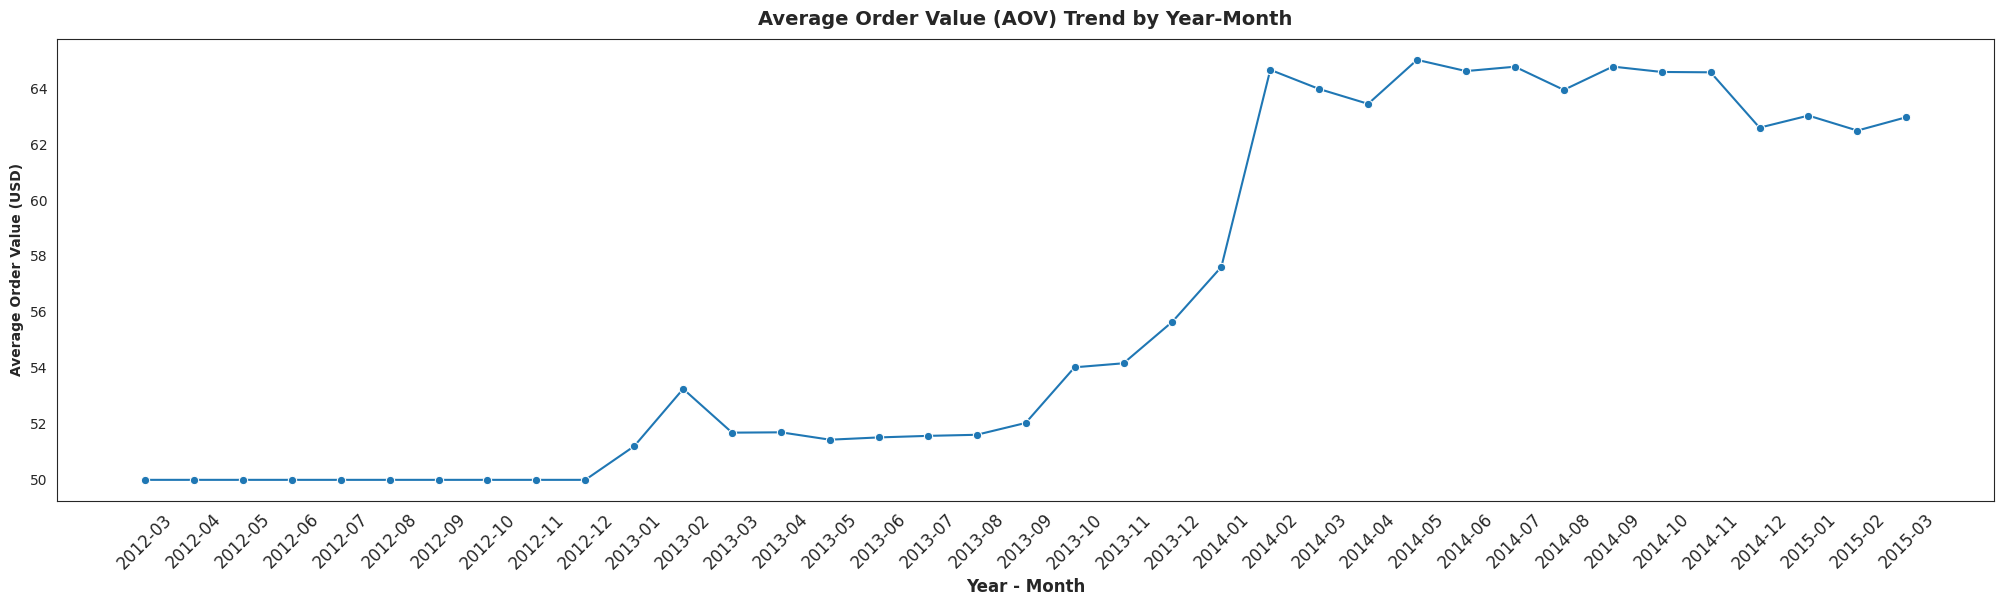

In [ ]:
plt.figure(figsize=(25, 6))
sns.lineplot(data=yr_quartely_sales, x='year_month', y='Average_order_value', marker='o')

plt.title('Average Order Value (AOV) Trend by Year-Month', pad=10, weight='bold',fontsize=14)
plt.xlabel('Year - Month', weight='bold',fontsize=12)
plt.ylabel('Average Order Value (USD)', weight='bold')
plt.xticks(rotation=45,fontsize=12)
plt.show()

AOV stayed flat through 2012 before entering a gradual upward trend in the following quarters it's a positive signal, since it suggests the business is earning more revenue per order without needing more traffic


---



### Seasonality: Monthly and Day-of-Week Sales

Two views of seasonality side by side: total sales aggregated across all
years, and total sales by day of week (useful for staffing
customer support and timing promotions).


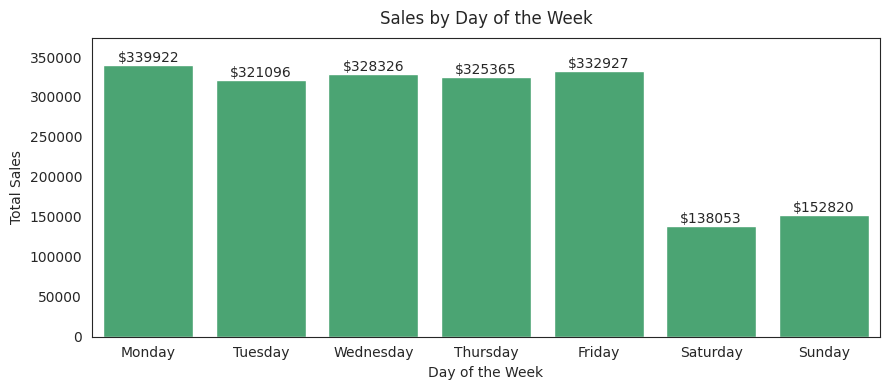

In [ ]:

dayofweek_sales = df_order_item.groupby('day_of_week')['price_usd'].sum().reset_index()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(9, 4))

ax = sns.barplot(data=dayofweek_sales, x='day_of_week', y='price_usd', order=days_order, color='mediumseagreen')
for i in ax.containers:
  plt.bar_label(i,fmt='$%.0f')
plt.title('Sales by Day of the Week', pad=10)
plt.xlabel('Day of the Week')
plt.ylabel('Total Sales')
plt.ylim(0, dayofweek_sales['price_usd'].max()*1.1)

plt.tight_layout()
plt.show()




 Weekday sales (Mon–Fri) are consistently strong and roughly even, while weekend sales, especially On Saturday  drop by more than half, suggesting this is a weekday-shopping heavy business (possibly B2B or desk-browsing behavior) rather than a weekend one.


---



## Customer Loyalty: New vs. Repeat Customers

**Business question:** Is growth being driven by acquiring new customers, by
repeat purchases from existing customers, or a healthy mix of both? A
business overly reliant on new-customer acquisition is more exposed to
rising ad costs, while a healthy repeat-purchase base is generally cheaper
to sustain.


In [ ]:
df_orders.head()


,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49


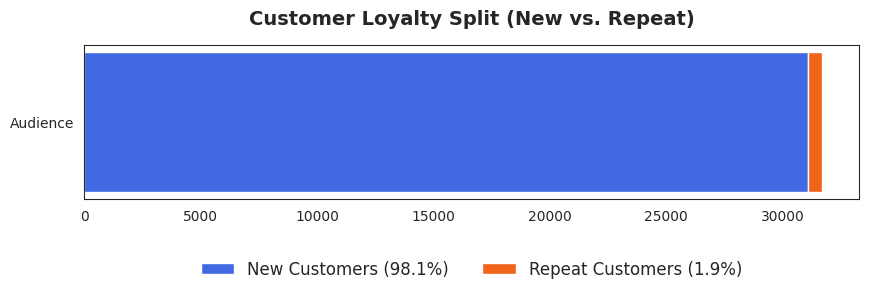

In [ ]:
# Count orders per user; a user with more than one order is a repeat customer
orders_per_user = df_orders.groupby('user_id')['order_id'].count().reset_index()

repeat_customers = int(np.where(orders_per_user['order_id'] > 1, 1, 0).sum())
total_customers = df_orders['user_id'].nunique()
new_customers = total_customers - repeat_customers

repeat_pct = (repeat_customers / total_customers) * 100
new_pct = (new_customers / total_customers) * 100

plt.figure(figsize=(10, 2))

# Stacked horizontal bar: 'left' offsets the second bar to start where the first ends
plt.barh('Audience', new_customers, color='royalblue', label=f'New Customers ({new_pct:.1f}%)')
plt.barh('Audience', repeat_customers, left=new_customers, color='#F26419',
          label=f'Repeat Customers ({repeat_pct:.1f}%)')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=2, frameon=False, fontsize=12)
plt.title('Customer Loyalty Split (New vs. Repeat)', weight='bold', fontsize=14, pad=15)
plt.show()


While the marketing team is driving massive acquisition to bring in 98.1% new buyers, the business is failing to retain them. With a repeat rate of just 1.9%, a huge amount of marketing spend is being wasted on one-time purchases instead of building long-term loyalty.

## Business Key Insights

1. **Traffic is good, but sales are low:**
- 472,871 sessions produced only 32,313 orders that's 6.83% conversion rate. The volume of traffic isn't the problem something between landing and purchase is.

2. **Nonbrand is the revenue engine & pilot isn't working well**

- nonbrand: 6.71% conversion but $1.35M in sales (by far the largest volume-driven revenue)

- pilot: weak on both 1.08% conversion rate and $3,743 in sales.

3. **Desktop converts nearly 3x better than mobile.**
- Desktop: 8.50% conversion (327,027 sessions).
- Mobile: 3.09% conversion (145,844 sessions).
- The mobile checkout process is likely too difficult.

4. **Cart abandonment is high abs stable.**
- Of 94,953 sessions that reached the cart, 62,640 abandoned it (66% abandonment rate).
- The trend line shows this dropped from over 77% in mid-2012 to 63% by early 2013, then stabilized between 64–67% through early 2015.
- Therefore, past fixes worked initially but then got stable, not improving.

5. **The landing page is the single biggest funnel leak bigger than checkout.**
- 472,871 landing views only 261,231 reach the product list.Around (45%) of our visitors leave the site from the very first page without even looking at our products. This is a largest drop than any single checkout step.

6. **Cross-sell is almost entirely untapped.**
- 76% of orders are single-item.
- The top product pair is "The Original Mr. Fuzzy" + "The Hudson River Mini Bear".

7. **"The Original Mr. Fuzzy" is both the profit engine and the biggest refund risk.**
- It drives \$1.21M gross sales and around \$677K net profit more than the other three products combined but its 5.11% return rate translates to \$61,838 in refunds the largest refund exposure of any product.
- "The Birthday Sugar Panda" has the highest rate 6.04% but a smaller dollar impact \$13,843 due to lower volume.
- Overall return rate across all products is 4.32%.

8. **Customer Retention is critically weak**
Two different metrics tell a layered story:

- Only 16.6% of sessions are returning visitors (most traffic never comes back to browse again)
- Only 1.9% of customers place a second order (98.1% are one-time buyers)

- The gap between these two numbers matters: even the small share of people who do come back to browse are converting into repeat buyers at a very low rate. This means fixing "return visits" alone won't fix retention there's a second leak between browsing-again and buying-again.

9. **Weekends are slow:**
- People buy a lot during the week, but sales drop by more than half on Saturdays and Sundays.



---




## Recommendations (Data Driven)

1. **Fix the homepage first:** We lose almost half our visitors the second they arrive. This is our biggest leak.

2. **Fix the mobile site:** 8.50% vs 3.09% conversion gap between desktop and mobile is too large. Buying on a phone is probably too difficult right now.

3. **Stop the "pilot" ads:** They aren't bringing in sales. Let's turn them off and stop wasting money.

4. Investigate why desktop_targeted and brand have so little volume despite converting well they may be under-invested rather than inherently small audiences.

5. **Suggest a bundle at checkout:** People already love buying the "Mr. Fuzzy" and the "Mini Bear" together. Let's add a quick "buy both" button to make it easier.

6. **Initiate Quality Control:** Investigate manufacturing, packaging, or product descriptions for "The Original Mr. Fuzzy" and "The Birthday Sugar Panda"
- Fixing the root cause of these specific returns will protect your largest net profit

7. **Fix retention before adding new customers**
- Fix the browsing leak: Re-engage past customers with post-purchase content, educational emails, or new product drop announcements to bring that 16.6% return-visit rate up.

- Fix the buying leak: Offer aggressive, personalized incentives (like a heavy discount on the second order) designed specifically to convert returning browsers into repeat buyers and beat the 1.9% repeat purchase rate.

8. **Re-investigate cart abandonment:**  Rate is around 64–67%  since 2013 suggests whatever fix worked in 2012 it's not working now.
- A fresh checkout audit is likely needed rather than assuming past improvements are still works well.

9. **Stimulate Weekend Sales:** Fill the Saturday and Sunday drop-off by launching weekend-only flash sales or limited-time promotional bundles.

- Shift promotional email and SMS sends to Friday afternoons or Saturday mornings to keep the brand top-of-mind during low-traffic periods.